# AOA Modeling Boundary Optimization

This notebook focuses on improving the hardest part of the task: separating the middle age band `age_6_8` from the two boundary classes.



## 1. Goal

Current experiments show that:
- `XGBClassifier_B` is the best classification baseline
- `age_6_8` is still the hardest class
- many mistakes happen near the `6` and `8` year cut points

This notebook therefore tests two targeted ideas:
1. weighted classification to give more attention to `age_6_8`
2. boundary-focused error analysis



In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 6)

ROOT = Path.cwd()
if ROOT.name == 'iteration2':
    ROOT = ROOT.parent.parent

FEATURE_B_PATH = ROOT / 'data/processed/iteration2/AoA_featureset_b_v3_freq2.csv'

FEATURE_B_PATH


PosixPath('/Users/datong/Documents/5120/Nurodiversity inclusive design/data/TP10_DS/data/processed/iteration2/AoA_featureset_b_v3_freq2.csv')

## 2. Load the current best feature set

We use `FeatureSet-B` because it was the strongest classification setup in the previous notebook.



In [2]:
df = pd.read_csv(FEATURE_B_PATH)
print('shape:', df.shape)
display(df.head())


shape: (9997, 18)


,Word,log_freq_pm,Nletters,Nphon,Nsyll,Perc_known_final,letters_per_syll,phon_per_syll,letters_per_phon,letters_x_syll,phon_x_syll,is_lemma_match,lemma_length_diff,Dom_PoS_SUBTLEX,pos_group,AoA_source,AoA_final,Age_Group
0,a,9.924088,1,1,1,1.000000,1.000000,1.000000,1.000000,1,1,1,0,Article,Function,AoA_Kup,2.893384,below_6
1,abandon,2.208059,7,7,3,1.000000,2.333333,2.333333,1.000000,21,21,1,0,Verb,Content,AoA_Kup,8.320000,age_8_plus
2,abandoned,2.659848,9,8,3,1.000000,3.000000,2.666667,1.125000,27,24,0,2,Verb,Content,AoA_Kup_lem,8.320000,age_8_plus
3,abbey,1.429467,5,3,2,0.857143,2.500000,1.500000,1.666667,10,6,1,0,Noun,Content,AoA_Kup,13.060000,age_8_plus
4,abdomen,1.470852,7,7,3,1.000000,2.333333,2.333333,1.000000,21,21,1,0,Noun,Content,AoA_Kup,8.610000,age_8_plus


## 3. Shared split and preprocessing

We keep the same stratified split style as before so the new results remain comparable.



In [3]:
feature_cols = [c for c in df.columns if c not in ['Word', 'AoA_final', 'Age_Group']]
numeric_cols = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in feature_cols if c not in numeric_cols]

train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.2,
    stratify=df['Age_Group'],
    random_state=42,
)

X_train = df.loc[train_idx, feature_cols].copy()
X_test = df.loc[test_idx, feature_cols].copy()
y_train = df.loc[train_idx, 'Age_Group'].copy()
y_test = df.loc[test_idx, 'Age_Group'].copy()

preprocess = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]), numeric_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ]), categorical_cols),
])

label_order = ['below_6', 'age_6_8', 'age_8_plus']
label_encoder = LabelEncoder()
label_encoder.fit(label_order)
y_train_encoded = label_encoder.transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

X_train_ready = preprocess.fit_transform(X_train)
X_test_ready = preprocess.transform(X_test)

print('train:', X_train_ready.shape)
print('test:', X_test_ready.shape)


train: (7997, 38)
test: (2000, 38)


## 4. Baseline vs weighted XGBoost

The baseline model treats every training row equally. The weighted version gives more importance to `age_6_8`, because that middle class is currently under-recovered.



In [4]:
def fit_predict_xgb(X_train_ready, X_test_ready, y_train_encoded, y_test, sample_weight=None, title='XGB'):
    model = XGBClassifier(
        n_estimators=350,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='multi:softprob',
        eval_metric='mlogloss',
        random_state=42,
    )
    model.fit(X_train_ready, y_train_encoded, sample_weight=sample_weight)
    pred_encoded = model.predict(X_test_ready)
    pred = label_encoder.inverse_transform(pred_encoded)
    report_text = classification_report(y_test, pred, zero_division=0)
    report_dict = classification_report(y_test, pred, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_test, pred, labels=label_order)
    summary = {
        'model': title,
        'accuracy': accuracy_score(y_test, pred),
        'macro_f1': f1_score(y_test, pred, average='macro'),
        'weighted_f1': f1_score(y_test, pred, average='weighted'),
        'age_6_8_precision': report_dict['age_6_8']['precision'],
        'age_6_8_recall': report_dict['age_6_8']['recall'],
        'age_6_8_f1': report_dict['age_6_8']['f1-score'],
    }
    return model, pred, cm, report_text, summary


baseline_model, baseline_pred, baseline_cm, baseline_report, baseline_summary = fit_predict_xgb(
    X_train_ready,
    X_test_ready,
    y_train_encoded,
    y_test,
    sample_weight=None,
    title='XGB_Baseline_B',
)

weights = pd.Series(1.0, index=y_train.index)
weights[y_train == 'age_6_8'] = 2.0

weighted_model, weighted_pred, weighted_cm, weighted_report, weighted_summary = fit_predict_xgb(
    X_train_ready,
    X_test_ready,
    y_train_encoded,
    y_test,
    sample_weight=weights.to_numpy(),
    title='XGB_Weighted_age_6_8',
)

print('Baseline report')
print(baseline_report)
print('Weighted report')
print(weighted_report)
display(pd.DataFrame([baseline_summary, weighted_summary]).round(4))


Baseline report
              precision    recall  f1-score   support

     age_6_8       0.39      0.20      0.26       544
  age_8_plus       0.65      0.82      0.73       849
     below_6       0.60      0.66      0.63       607

    accuracy                           0.60      2000
   macro avg       0.55      0.56      0.54      2000
weighted avg       0.57      0.60      0.57      2000

Weighted report
              precision    recall  f1-score   support

     age_6_8       0.35      0.58      0.43       544
  age_8_plus       0.72      0.59      0.65       849
     below_6       0.69      0.44      0.54       607

    accuracy                           0.54      2000
   macro avg       0.58      0.54      0.54      2000
weighted avg       0.61      0.54      0.56      2000



,model,accuracy,macro_f1,weighted_f1,age_6_8_precision,age_6_8_recall,age_6_8_f1
0,XGB_Baseline_B,0.5995,0.5380,0.5695,0.3919,0.1967,0.2619
1,XGB_Weighted_age_6_8,0.5435,0.5408,0.5574,0.3454,0.5772,0.4322


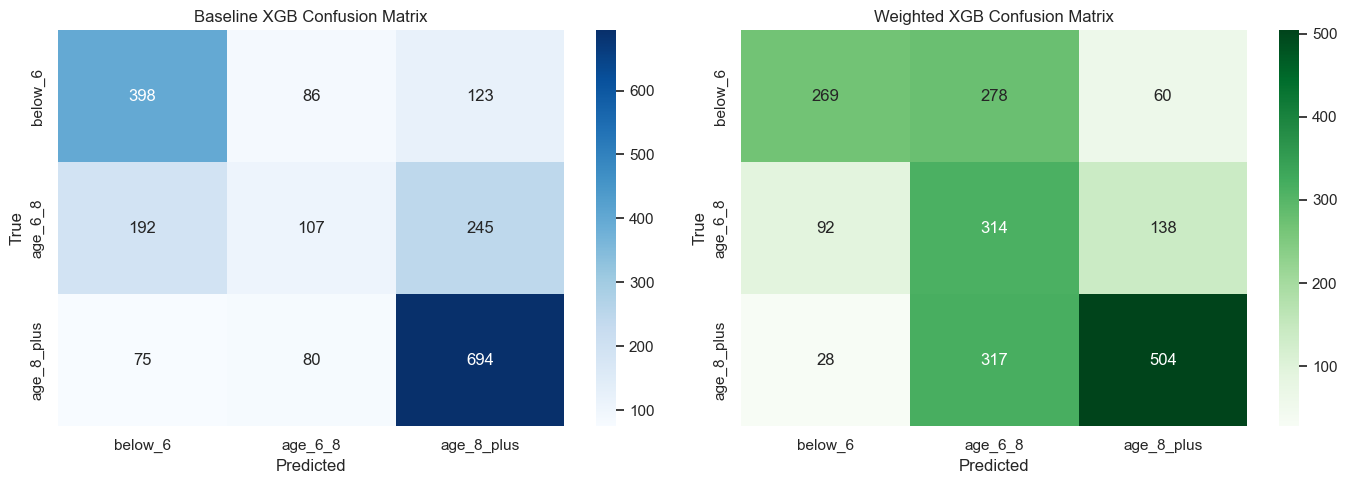

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(baseline_cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_order, yticklabels=label_order, ax=axes[0])
axes[0].set_title('Baseline XGB Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(weighted_cm, annot=True, fmt='d', cmap='Greens', xticklabels=label_order, yticklabels=label_order, ax=axes[1])
axes[1].set_title('Weighted XGB Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()


## 5. Boundary-focused error analysis

Now we look directly at the hard region: words whose true `AoA_final` is close to the `6` and `8` year cut points.



In [6]:
analysis_df = df.loc[test_idx, ['Word', 'AoA_final', 'Age_Group']].copy()
analysis_df['baseline_pred'] = baseline_pred
analysis_df['weighted_pred'] = weighted_pred
analysis_df['baseline_correct'] = analysis_df['Age_Group'] == analysis_df['baseline_pred']
analysis_df['weighted_correct'] = analysis_df['Age_Group'] == analysis_df['weighted_pred']

analysis_df['boundary_zone'] = pd.cut(
    analysis_df['AoA_final'],
    bins=[-np.inf, 5.5, 6.5, 7.5, 8.5, np.inf],
    labels=['below_5.5', 'near_6', 'between_6.5_7.5', 'near_8', 'above_8.5']
)

display(analysis_df.head())


,Word,AoA_final,Age_Group,baseline_pred,weighted_pred,baseline_correct,weighted_correct,boundary_zone
4072,happiest,2.72,below_6,below_6,below_6,True,True,below_5.5
3071,eternal,8.26,age_8_plus,age_8_plus,age_8_plus,True,True,near_8
4561,input,10.67,age_8_plus,age_8_plus,age_8_plus,True,True,above_8.5
6443,pistol,7.28,age_6_8,age_8_plus,age_6_8,False,True,between_6.5_7.5
3085,events,7.81,age_6_8,below_6,age_6_8,False,True,near_8


In [7]:
boundary_accuracy = analysis_df.groupby('boundary_zone')[['baseline_correct', 'weighted_correct']].mean().round(4)
display(boundary_accuracy)

boundary_counts = analysis_df['boundary_zone'].value_counts().sort_index().to_frame('count')
display(boundary_counts)


/var/folders/xy/3853xvsd0xb3mwrdg3w9cwnr0000gn/T/ipykernel_6754/3463665585.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  boundary_accuracy = analysis_df.groupby('boundary_zone')[['baseline_correct', 'weighted_correct']].mean().round(4)


,baseline_correct,weighted_correct
boundary_zone,,
below_5.5,0.7032,0.4905
near_6,0.3383,0.4201
between_6.5_7.5,0.1993,0.6089
near_8,0.4429,0.4857
above_8.5,0.8454,0.6241


,count
boundary_zone,
below_5.5,475
near_6,269
between_6.5_7.5,271
near_8,280
above_8.5,705


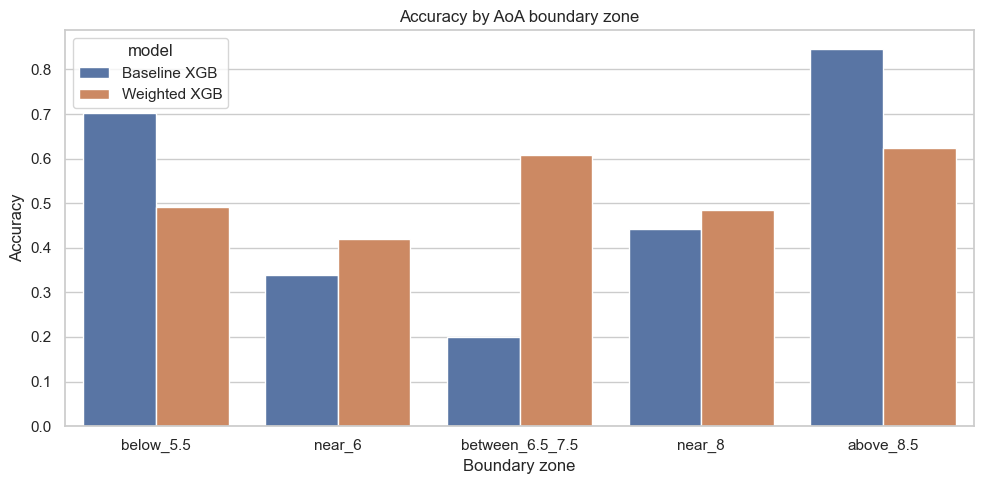

In [8]:
plot_df = boundary_accuracy.reset_index().melt(id_vars='boundary_zone', value_name='accuracy', var_name='model')
plot_df['model'] = plot_df['model'].replace({
    'baseline_correct': 'Baseline XGB',
    'weighted_correct': 'Weighted XGB',
})

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x='boundary_zone', y='accuracy', hue='model')
plt.title('Accuracy by AoA boundary zone')
plt.xlabel('Boundary zone')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()


## 6. Misclassified middle-band words

This section collects the true `age_6_8` words that are still misclassified, so we can inspect whether the remaining errors cluster near the boundary.



In [9]:
middle_errors_baseline = analysis_df[(analysis_df['Age_Group'] == 'age_6_8') & (~analysis_df['baseline_correct'])].copy()
middle_errors_weighted = analysis_df[(analysis_df['Age_Group'] == 'age_6_8') & (~analysis_df['weighted_correct'])].copy()

print('Baseline middle-band errors:', len(middle_errors_baseline))
print('Weighted middle-band errors:', len(middle_errors_weighted))

display(middle_errors_baseline[['Word', 'AoA_final', 'Age_Group', 'baseline_pred', 'boundary_zone']].head(20))
display(middle_errors_weighted[['Word', 'AoA_final', 'Age_Group', 'weighted_pred', 'boundary_zone']].head(20))


Baseline middle-band errors: 437
Weighted middle-band errors: 230


,Word,AoA_final,Age_Group,baseline_pred,boundary_zone
6443,pistol,7.280000,age_6_8,age_8_plus,between_6.5_7.5
3085,events,7.810000,age_6_8,below_6,near_8
3646,frosty,6.330000,age_6_8,age_8_plus,near_6
8295,speech,6.220000,age_6_8,below_6,near_6
2163,cricket,7.720000,age_6_8,age_8_plus,near_8
2357,decided,7.200000,age_6_8,below_6,between_6.5_7.5
3922,greasy,6.390000,age_6_8,age_8_plus,near_6
689,based,6.420000,age_6_8,below_6,near_6
7994,since,6.850480,age_6_8,below_6,between_6.5_7.5
1692,cockroach,6.250000,age_6_8,age_8_plus,near_6


,Word,AoA_final,Age_Group,weighted_pred,boundary_zone
3646,frosty,6.330000,age_6_8,age_8_plus,near_6
2163,cricket,7.720000,age_6_8,age_8_plus,near_8
3922,greasy,6.390000,age_6_8,age_8_plus,near_6
689,based,6.420000,age_6_8,below_6,near_6
7994,since,6.850480,age_6_8,below_6,between_6.5_7.5
1692,cockroach,6.250000,age_6_8,age_8_plus,near_6
4369,hung,6.680000,age_6_8,below_6,between_6.5_7.5
3481,flour,6.890000,age_6_8,age_8_plus,between_6.5_7.5
3086,eventually,7.031649,age_6_8,age_8_plus,between_6.5_7.5
5317,manual,7.570000,age_6_8,age_8_plus,near_8


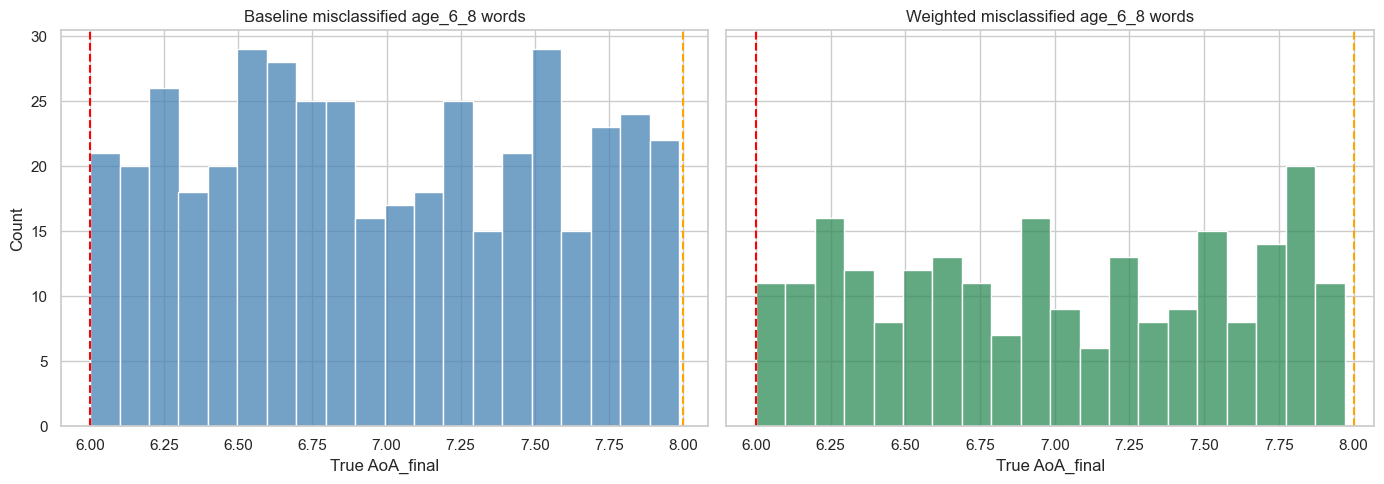

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

sns.histplot(middle_errors_baseline['AoA_final'], bins=20, ax=axes[0], color='steelblue')
axes[0].axvline(6, color='red', linestyle='--')
axes[0].axvline(8, color='orange', linestyle='--')
axes[0].set_title('Baseline misclassified age_6_8 words')
axes[0].set_xlabel('True AoA_final')

sns.histplot(middle_errors_weighted['AoA_final'], bins=20, ax=axes[1], color='seagreen')
axes[1].axvline(6, color='red', linestyle='--')
axes[1].axvline(8, color='orange', linestyle='--')
axes[1].set_title('Weighted misclassified age_6_8 words')
axes[1].set_xlabel('True AoA_final')

plt.tight_layout()
plt.show()


## 7. Next step

If weighting improves middle-class recall without damaging the other two classes too much, it is worth keeping. If the main errors still sit right around `6` and `8`, the next method to try should be ordinal or boundary-aware modeling rather than endlessly adding generic features.

